# 手写数字识别（教学版 Notebook）

目标：用 **MNIST** 跑通一个可复现的训练与评估流程，并在 notebook 里把关键技术步骤讲清楚：
- 数据是什么样（EDA）
- 预处理/归一化在做什么
- CNN 输出 logits 是什么
- 一次前向/反向传播发生了什么
- 训练曲线怎么看
- 混淆矩阵与误分类样例如何指导改进

本 notebook 复用 `src/` 里的代码（数据加载/模型/训练引擎），但不会用命令行调用（不跑 `subprocess`）。

> 提醒：最终评分通常看隐藏测试集准确率；但教学版先把流程看懂，再做更高准确率的改进会更稳。


## 0) 环境检查与导入依赖
如果这里导入失败，说明当前 kernel 没装依赖：请先运行 `python -m pip install -r requirements.txt`。

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

from src.config import ExperimentConfig, ensure_project_paths
from src.data import build_transform, create_dataloaders
from src.engine import fit
from src.model import SmallCNN

# 尽量让中文能显示（若系统缺字体可能仍会出现 warning，不影响运行）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('Python 版本:', sys.version)
print('解释器路径:', sys.executable)
print('当前工作目录:', Path.cwd())
print('是否包含 src/ 目录?:', (Path.cwd() / 'src').is_dir())
print('Torch 版本:', torch.__version__)


Python 版本: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
解释器路径: c:\Users\claredz\anaconda3\python.exe
当前工作目录: e:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline
是否包含 src/ 目录?: True
Torch 版本: 2.11.0+cu128


## 1) 实验配置与可复现性
这里先固定实验参数（后面调参只改一个变量，方便对比）。

In [3]:
project_root = Path('.').resolve()

config = ExperimentConfig(
    project_root=project_root,
    dataset_name='mnist',
    batch_size=64,
    validation_split=0.2,
    image_size=28,
    learning_rate=1e-3,
    epochs=3,
    seed=42,
    num_workers=0,
)

paths = ensure_project_paths(config)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('使用设备:', device)
print('数据目录:', config.resolved_data_dir())
print('输出目录:', paths.outputs_dir)


使用设备: cpu
数据目录: E:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline\data
输出目录: E:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline\outputs


## 2) 数据理解（EDA）：样本长什么样？类别是否均衡？
我们先用 *不做归一化* 的方式预览 MNIST（更符合直觉），再进入训练用的 transform。

MNIST 训练集样本数: 60000
每个数字的样本数: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


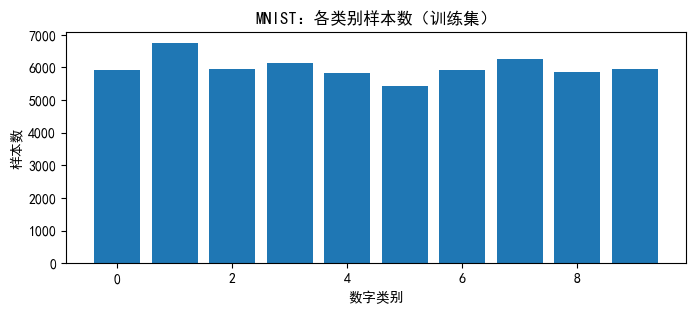

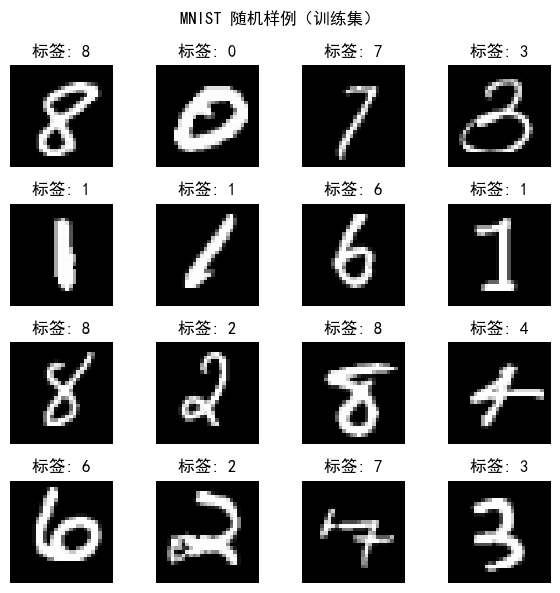

像素范围（ToTensor 后）：min/max = 0.0 1.0
像素均值/方差（粗略抽样）：mean/std = 0.1240721344947815 0.30236390233039856


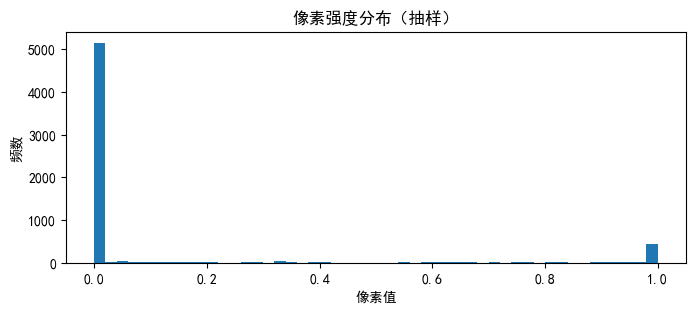

In [4]:
from torchvision import datasets, transforms

raw_dataset = datasets.MNIST(
    root=str(config.resolved_data_dir()),
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

print('MNIST 训练集样本数:', len(raw_dataset))
targets = raw_dataset.targets.numpy()
counts = np.bincount(targets, minlength=10)
print('每个数字的样本数:', {i: int(c) for i, c in enumerate(counts)})

plt.figure(figsize=(8, 3))
plt.bar(list(range(10)), counts)
plt.title('MNIST：各类别样本数（训练集）')
plt.xlabel('数字类别')
plt.ylabel('样本数')
plt.show()

# 随机展示一些样例
rng = np.random.default_rng(config.seed)
indices = rng.choice(len(raw_dataset), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, idx in zip(axes.flatten(), indices):
    img, label = raw_dataset[int(idx)]
    ax.imshow(img.squeeze(0), cmap='gray')
    ax.set_title(f'标签: {int(label)}')
    ax.axis('off')
plt.suptitle('MNIST 随机样例（训练集）')
plt.tight_layout()
plt.show()

# 数值分布（像素强度）
sample_pixels = []
for i in indices[:8]:
    img, _ = raw_dataset[int(i)]
    sample_pixels.append(img.flatten().numpy())
sample_pixels = np.concatenate(sample_pixels)

print('像素范围（ToTensor 后）：min/max =', float(sample_pixels.min()), float(sample_pixels.max()))
print('像素均值/方差（粗略抽样）：mean/std =', float(sample_pixels.mean()), float(sample_pixels.std()))

plt.figure(figsize=(8, 3))
plt.hist(sample_pixels, bins=50)
plt.title('像素强度分布（抽样）')
plt.xlabel('像素值')
plt.ylabel('频数')
plt.show()


## 3) 训练用预处理：Resize / ToTensor / Normalize
训练时我们会做 Normalize：`(x - 0.5) / 0.5`，把像素从 `[0,1]` 映射到大致 `[-1, 1]`。
这一节我们用同一张图对比预处理前后的数值范围，并说明为什么这样做有利于训练稳定。

标签: 8
未归一化范围 [0,1]：min/max = 0.0 1.0
归一化后范围：min/max = -1.0 1.0


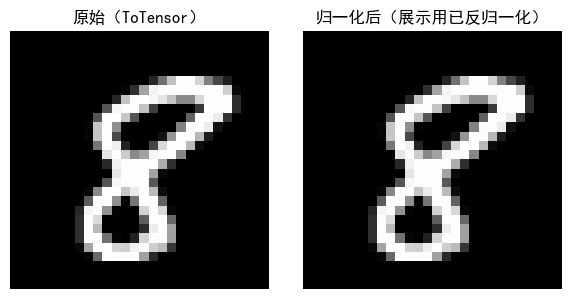

In [5]:
# 取一张样例图做对比
img_tensor, label = raw_dataset[int(indices[0])]

train_transform = build_transform(image_size=config.image_size, augment=False)

# raw_dataset 这里拿到的是 Tensor；为了复用 transform（它接收 PIL），这里用原始 PIL 图像
pil_img, _ = datasets.MNIST(root=str(config.resolved_data_dir()), train=True, download=False)[int(indices[0])]
normalized = train_transform(pil_img)

print('标签:', int(label))
print('未归一化范围 [0,1]：min/max =', float(img_tensor.min()), float(img_tensor.max()))
print('归一化后范围：min/max =', float(normalized.min()), float(normalized.max()))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_tensor.squeeze(0), cmap='gray')
axes[0].set_title('原始（ToTensor）')
axes[0].axis('off')

# 为了可视化 normalized，把它反归一化回 [0,1]
unnorm = (normalized * 0.5 + 0.5).clamp(0, 1)
axes[1].imshow(unnorm.squeeze(0), cmap='gray')
axes[1].set_title('归一化后（展示用已反归一化）')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 4) DataLoader：batch 的形状与含义
我们用 `create_dataloaders(config)` 创建 train/val，并观察一个 batch 的张量形状：
- images: `(B, 1, 28, 28)`
- labels: `(B,)`（每个样本的类别索引）

images.shape = (64, 1, 28, 28)
labels.shape = (64,)
labels[:10] = [7, 9, 0, 4, 1, 0, 5, 4, 8, 3]
images 数值范围：min/max = -1.0 1.0


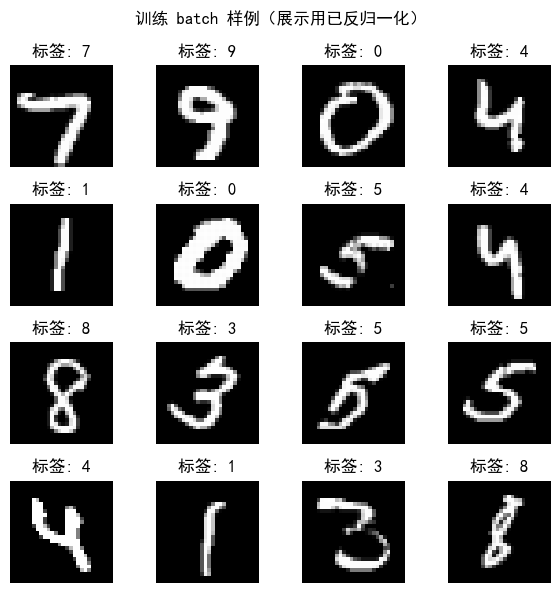

In [6]:
train_loader, val_loader = create_dataloaders(config)

images, labels = next(iter(train_loader))
print('images.shape =', tuple(images.shape))
print('labels.shape =', tuple(labels.shape))
print('labels[:10] =', labels[:10].tolist())
print('images 数值范围：min/max =', float(images.min()), float(images.max()))

# 展示一个 batch 的前 16 张（注意这里数据是归一化后的，所以展示时要反归一化）
show = (images[:16] * 0.5 + 0.5).clamp(0, 1)
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, img, y in zip(axes.flatten(), show, labels[:16]):
    ax.imshow(img.squeeze(0), cmap='gray')
    ax.set_title(f'标签: {int(y)}')
    ax.axis('off')
plt.suptitle('训练 batch 样例（展示用已反归一化）')
plt.tight_layout()
plt.show()


## 5) 模型：SmallCNN 的结构、参数量、输出 logits
重点：模型输出是 `(B, 10)` 的 **logits**，不是概率。训练用 `CrossEntropyLoss` 时，内部会处理 softmax。

In [7]:
model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(device)
print(model)

param_count = sum(p.numel() for p in model.parameters())
print('参数量:', param_count)

model.eval()
with torch.no_grad():
    logits = model(images.to(device))

print('logits.shape =', tuple(logits.shape))

probs = torch.softmax(logits, dim=1)
top_probs, top_idx = probs[0].topk(3)
print('第 1 个样本：真实标签 =', int(labels[0]))
print('top-3 预测:')
for p, k in zip(top_probs.cpu().tolist(), top_idx.cpu().tolist()):
    print(f'  预测 {k}，概率 {p:.4f}')


SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
参数量: 421642
logits.shape = (64, 10)
第 1 个样本：真实标签 = 7
top-3 预测:
  预测 3，概率 0.1115
  预测 5，概率 0.1067
  预测 0，概率 0.1049


## 6) 训练机制：单个 batch 的一次反向传播（看见梯度）
这一节只做一个 batch，目的是直观看到：
- loss 是如何计算的
- backward 后梯度是否存在
- optimizer.step() 后参数是否变化

In [8]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

model.train()
optimizer.zero_grad()
logits = model(images.to(device))
loss = criterion(logits, labels.to(device))
loss.backward()

# 观察某一层参数的梯度（这里只是示例：看梯度是否为 None，以及大概大小）
some_param = None
for name, p in model.named_parameters():
    if p.grad is not None:
        some_param = (name, p)
        break

print('单 batch loss =', float(loss.item()))
if some_param is not None:
    name, p = some_param
    print('示例参数:', name)
    print('grad.abs().mean() =', float(p.grad.abs().mean().item()))

# 做一次参数更新
before = next(model.parameters()).detach().clone()
optimizer.step()
after = next(model.parameters()).detach().clone()
print('参数是否发生变化:', bool(torch.any(before != after).item()))


单 batch loss = 2.30301570892334
示例参数: features.0.weight
grad.abs().mean() = 0.0015772278420627117
参数是否发生变化: True


## 7) 完整训练：按 epoch 训练并记录曲线
这里调用 `src.engine.fit()`（会自动保存 checkpoint 与 history/曲线图）。训练完成后我们直接在 notebook 里画出曲线。

训练结束，best_val_accuracy = 0.987
checkpoint 路径 = E:\ALL\学习\AI导论作业-识别手写数字\.worktrees\baseline\outputs\checkpoints\best_model.pt


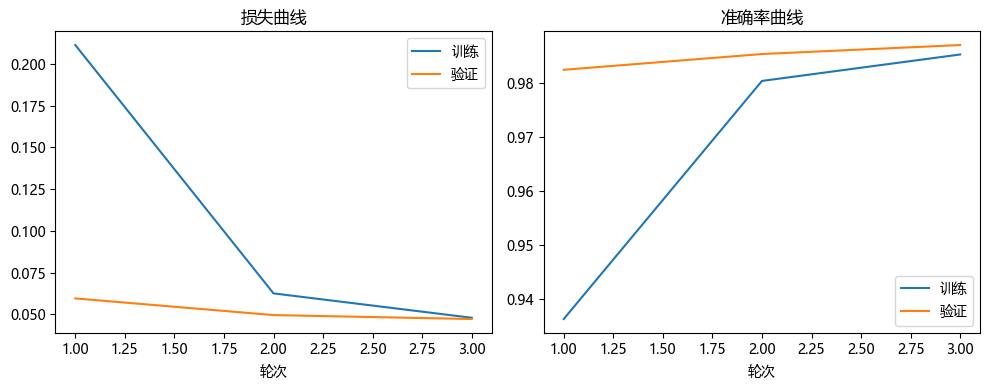

In [9]:
# 重新初始化模型（避免上一步单 batch 更新影响演示）
model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(device)

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    paths=paths,
    device=device,
)

print('训练结束，best_val_accuracy =', history['best_val_accuracy'])
print('checkpoint 路径 =', paths.checkpoints_dir / 'best_model.pt')

epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs, history['train_loss'], label='训练')
axes[0].plot(epochs, history['val_loss'], label='验证')
axes[0].set_title('损失曲线')
axes[0].set_xlabel('轮次')
axes[0].legend()

axes[1].plot(epochs, history['train_accuracy'], label='训练')
axes[1].plot(epochs, history['val_accuracy'], label='验证')
axes[1].set_title('准确率曲线')
axes[1].set_xlabel('轮次')
axes[1].legend()

plt.tight_layout()
plt.show()


## 8) 评估与误差分析：混淆矩阵 + 每类指标 + 典型误分类
我们在验证集上做推理，并输出：
- 混淆矩阵（计数版 + 归一化版）
- 每类 precision/recall/F1（表格）
- 误分类样例（优先展示“错得很自信”的样本）

验证集准确率: 0.9869999885559082


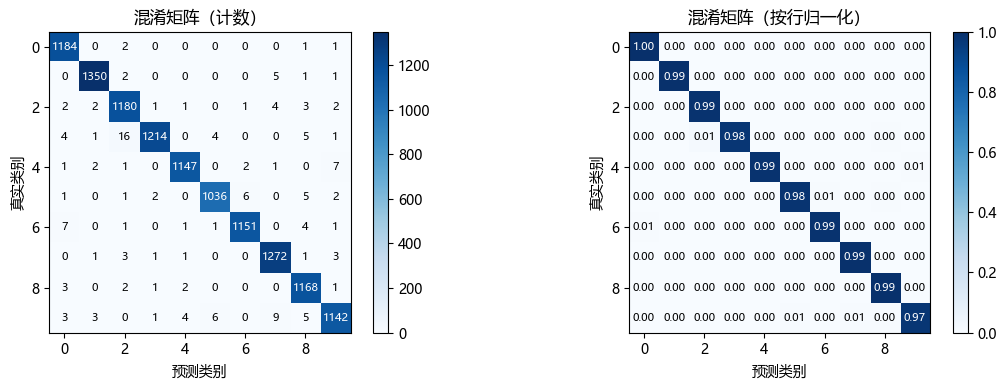

,precision,recall,f1-score,support
类别,,,,
0,0.982573,0.996633,0.989553,1188.0
1,0.993377,0.993377,0.993377,1359.0
2,0.976821,0.986622,0.981697,1196.0
3,0.995082,0.975100,0.984990,1245.0
4,0.992215,0.987941,0.990073,1161.0
5,0.989494,0.983856,0.986667,1053.0
6,0.992241,0.987136,0.989682,1166.0
7,0.985283,0.992200,0.988729,1282.0
8,0.979044,0.992353,0.985654,1177.0


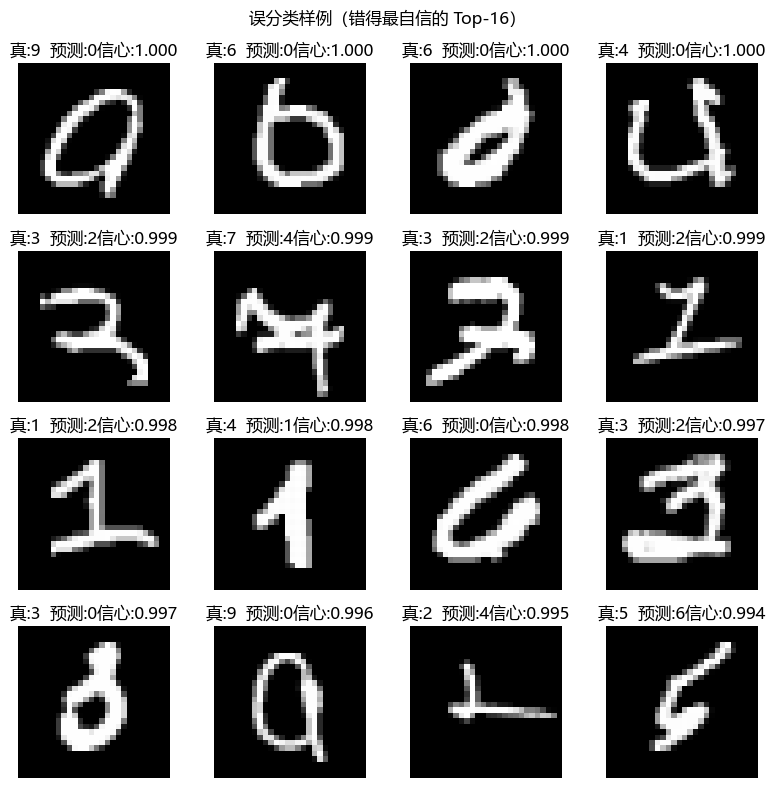

In [10]:
checkpoint = torch.load(paths.checkpoints_dir / 'best_model.pt', map_location=device)
eval_model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(device)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model.eval()

all_images = []
all_labels = []
all_logits = []

with torch.no_grad():
    for batch_images, batch_labels in val_loader:
        batch_logits = eval_model(batch_images.to(device)).cpu()
        all_images.append(batch_images.cpu())
        all_labels.append(batch_labels.cpu())
        all_logits.append(batch_logits)

images_val = torch.cat(all_images, dim=0)
y_true = torch.cat(all_labels, dim=0)
logits_val = torch.cat(all_logits, dim=0)
y_pred = logits_val.argmax(dim=1)

acc = float((y_true == y_pred).float().mean().item())
print('验证集准确率:', acc)

cm = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=list(range(10)))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('混淆矩阵（计数）')
axes[0].set_xlabel('预测类别')
axes[0].set_ylabel('真实类别')

threshold = cm.max() / 2.0 if cm.size else 0
for i in range(10):
    for j in range(10):
        v = int(cm[i, j])
        axes[0].text(
            j,
            i,
            str(v),
            ha='center',
            va='center',
            color='white' if v > threshold else 'black',
            fontsize=8,
        )

im1 = axes[1].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('混淆矩阵（按行归一化）')
axes[1].set_xlabel('预测类别')
axes[1].set_ylabel('真实类别')

for i in range(10):
    for j in range(10):
        v = float(cm_norm[i, j])
        axes[1].text(
            j,
            i,
            f'{v:.2f}',
            ha='center',
            va='center',
            color='white' if v > 0.5 else 'black',
            fontsize=8,
        )

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

report = classification_report(y_true.numpy(), y_pred.numpy(), digits=4, output_dict=True)
# 只取 0-9 的每类指标
per_class = {str(i): report[str(i)] for i in range(10)}

import pandas as pd
df = pd.DataFrame(per_class).T[['precision', 'recall', 'f1-score', 'support']]
df.index.name = '类别'
display(df)

# 错得很自信的样例（预测概率最高但预测错）
probs_val = torch.softmax(logits_val, dim=1)
pred_prob = probs_val[torch.arange(len(y_pred)), y_pred]
wrong = (y_pred != y_true)
wrong_indices = torch.where(wrong)[0]

if len(wrong_indices) == 0:
    print('本次验证集中没有误分类（通常是 epochs 太少时也可能有）。')
else:
    # 按“错得最自信”排序
    wrong_sorted = wrong_indices[torch.argsort(pred_prob[wrong_indices], descending=True)]
    topk = wrong_sorted[:16]

    show = (images_val[topk] * 0.5 + 0.5).clamp(0, 1)
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for ax, img, t, p, prob in zip(axes.flatten(), show, y_true[topk], y_pred[topk], pred_prob[topk]):
        ax.imshow(img.squeeze(0), cmap='gray')
        ax.set_title(f'真:{int(t)}  预测:{int(p)}信心:{float(prob):.3f}')
        ax.axis('off')
    plt.suptitle('误分类样例（错得最自信的 Top-16）')
    plt.tight_layout()
    plt.show()


## 9) 预留入口：将来接入外部 val / test
后续老师开放的验证/测试数据，常见有两种形式：

### A) 仍然是 MNIST 风格
你可以把它当作额外的 `DataLoader` 来评估（不要把 test 反复刷成调参目标）。

### B) 文件夹数据（已支持）
如果数据按 `root/0..9/*.png` 组织，可以用 `dataset_name='folder'` + `data_dir=...`：

```python
config_ext = ExperimentConfig(
    project_root=project_root,
    dataset_name='folder',
    data_dir=Path('你的数据根目录'),
    batch_size=64,
    validation_split=0.2,
    epochs=3,
)
train_loader, val_loader = create_dataloaders(config_ext)
```

无标签测试集预测导出则使用 `src/predict.py` 的逻辑（后续我们会在教学版里再加一节“无标签导出与对齐格式”）。